# Polyagamma GP Negative Binomial Demo On The DANDI Grid-Cell Dataset

This notebook adapts `pg_negative_binomial_learn_r_demo.ipynb` to the
NeMoS grid-cell tutorial dataset from Dandiset `000582`.

The observation model stays the same:

- inputs are 2D positions
- outputs are binned spike counts
- the count likelihood is negative binomial with learned `r`
- the latent log-intensity is modeled by the Poly-Gamma GP regressor

To match the synthetic notebook's geometry, the position predictors are
linearly normalized onto `[-1, 1]^2` before fitting.

This notebook was validated with the repo-local virtualenv at
`../venv/bin/python`. The workspace's default Anaconda Python 3.13
crashed inside `reg.fit(...)` for this compiled GP stack.


In [27]:
import os
import sys
import time
from pathlib import Path
from urllib.request import urlretrieve

import h5py
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

ROOT = Path.cwd().resolve()
PARENT = ROOT.parent
if str(PARENT) not in sys.path:
    sys.path.append(str(PARENT))

from pg_classifier import PolyagammaGPNegativeBinomialRegressor

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(suppress=True, precision=4)


## Download The NWB Session

The PDF points to the same session used in the NeMoS tutorial:

- Dandiset: `000582`
- Version: `0.251111.2151`
- File: `sub-11265/sub-11265_ses-07020602_behavior+ecephys.nwb`

The file is about 18 MB, so downloading it directly into the repo is
cheap enough for a notebook workflow.


In [28]:
DANDISET_ID = "000582"
DANDI_VERSION = "0.251111.2151"
ASSET_ID = "8a9de801-4be1-4068-9570-e6d7e168dbeb"
DOWNLOAD_URL = f"https://api.dandiarchive.org/api/assets/{ASSET_ID}/download/"

NWB_PATH = ROOT / "data" / "dandi_000582" / "sub-11265_ses-07020602_behavior+ecephys.nwb"
NWB_PATH.parent.mkdir(parents=True, exist_ok=True)

if not NWB_PATH.exists():
    print(f"Downloading {NWB_PATH.name} from DANDI ...")
    urlretrieve(DOWNLOAD_URL, NWB_PATH)

print(f"NWB path: {NWB_PATH}")
print(f"Size: {NWB_PATH.stat().st_size / 1e6:.2f} MB")


NWB path: /Users/colecitrenbaum/Documents/GPs/gp-quadrature/polyagamma_classification/data/dandi_000582/sub-11265_ses-07020602_behavior+ecephys.nwb
Size: 18.13 MB


## Load The Session And Summarize Units

The NWB stores:

- LED 1 and LED 2 position traces sampled every 20 ms
- a concatenated spike-time vector with `spike_times_index` offsets

As in the NeMoS tutorial, we use `SpatialSeriesLED1` as the position
input and focus on neuron `7` (`t7c3`), the same cell highlighted there.


In [29]:
def decode_str(x):
    return x.decode() if isinstance(x, bytes) else str(x)


def extract_unit_spike_times(spike_times, spike_times_index, unit_index):
    start = 0 if unit_index == 0 else int(spike_times_index[unit_index - 1])
    stop = int(spike_times_index[unit_index])
    return spike_times[start:stop]


with h5py.File(NWB_PATH, "r") as f:
    position = f["processing/behavior/Position/SpatialSeriesLED1/data"][:]
    position_t = f["processing/behavior/Position/SpatialSeriesLED1/timestamps"][:]
    spike_times = f["units/spike_times"][:]
    spike_times_index = f["units/spike_times_index"][:]
    unit_names = [decode_str(x) for x in f["units/unit_name"][:]]

duration_sec = float(position_t[-1] - position_t[0])
unit_summary = []
for unit_index, unit_name in enumerate(unit_names):
    unit_spikes = extract_unit_spike_times(spike_times, spike_times_index, unit_index)
    unit_summary.append(
        {
            "unit": unit_index,
            "name": unit_name,
            "n_spikes": int(unit_spikes.size),
            "mean_rate_hz": float(unit_spikes.size / duration_sec),
        }
    )

unit_summary


[{'unit': 0,
  'name': 't2c1',
  'n_spikes': 1625,
  'mean_rate_hz': 2.7084236141204707},
 {'unit': 1,
  'name': 't2c2',
  'n_spikes': 858,
  'mean_rate_hz': 1.4300476682556085},
 {'unit': 2,
  'name': 't4c1',
  'n_spikes': 2081,
  'mean_rate_hz': 3.4684489482982763},
 {'unit': 3,
  'name': 't5c2',
  'n_spikes': 712,
  'mean_rate_hz': 1.1867062235407846},
 {'unit': 4,
  'name': 't5c3',
  'n_spikes': 1349,
  'mean_rate_hz': 2.248408280276009},
 {'unit': 5,
  'name': 't7c1',
  'n_spikes': 740,
  'mean_rate_hz': 1.2333744458148606},
 {'unit': 6,
  'name': 't7c2',
  'n_spikes': 243,
  'mean_rate_hz': 0.405013500450015},
 {'unit': 7,
  'name': 't7c3',
  'n_spikes': 1257,
  'mean_rate_hz': 2.0950698356611888}]

## Bin Counts And Normalize Position To `[-1, 1]^2`

The original synthetic notebook uses predictors that already live inside
a square box around `[-1, 1]^2`. To keep the kernel lengthscale on the
same scale, we linearly remap the interpolated position trace to that
same domain.

By default the notebook trains on all binned observations. If you want
the earlier stride-based holdout behavior, set
`use_all_data_for_training = False` below.


In [30]:
neuron = 7
bin_size = 0.01
use_all_data_for_training = True
holdout_stride = 5
grid_size = 36

# ── Kernel selection ────────────────────────────────────────────────
# "squared_exponential" (default) or "matern"
# For matern, kernel_nu controls smoothness: 0.5, 1.5, 2.5 are common.
# Note: Matern requires more spectral nodes (heavier-tailed spectrum),
# so expect slower per-iteration cost than SE.
kernel_name = "squared_exponential"  # try "matern"
kernel_nu = 1.5                      # only used when kernel_name="matern"

unit_spikes = extract_unit_spike_times(spike_times, spike_times_index, neuron)

t0 = float(position_t[0])
t1 = float(position_t[-1])
n_bins = int(np.floor((t1 - t0) / bin_size))
edges = t0 + np.arange(n_bins + 1) * bin_size
centers = edges[:-1] + 0.5 * bin_size

counts_all = np.histogram(unit_spikes, bins=edges)[0].astype(np.float64)
position_interp = np.column_stack(
    [
        np.interp(centers, position_t, position[:, 0]),
        np.interp(centers, position_t, position[:, 1]),
    ]
)

coord_mins = position_interp.min(axis=0)
coord_maxs = position_interp.max(axis=0)
coord_span = np.where(coord_maxs > coord_mins, coord_maxs - coord_mins, 1.0)
X_all_np = 2.0 * (position_interp - coord_mins) / coord_span - 1.0

if use_all_data_for_training:
    mask_train = np.ones(n_bins, dtype=bool)
    mask_test = np.zeros(n_bins, dtype=bool)
    X_train_np = X_all_np
    y_train_np = counts_all
    X_test_np = np.empty((0, X_all_np.shape[1]), dtype=np.float64)
    y_test_np = np.empty((0,), dtype=np.float64)
else:
    mask_test = (np.arange(n_bins) % holdout_stride) == 0
    mask_train = np.logical_not(mask_test)
    X_train_np = X_all_np[mask_train]
    y_train_np = counts_all[mask_train]
    X_test_np = X_all_np[mask_test]
    y_test_np = counts_all[mask_test]

x_grid = np.linspace(coord_mins[0], coord_maxs[0], grid_size)
y_grid = np.linspace(coord_mins[1], coord_maxs[1], grid_size)
gx, gy = np.meshgrid(x_grid, y_grid, indexing="ij")
X_grid_original = np.column_stack([gx.reshape(-1), gy.reshape(-1)])
X_grid_np = 2.0 * (X_grid_original - coord_mins) / coord_span - 1.0

print(f"Neuron: {neuron} ({unit_names[neuron]})")
print(f"Kernel: {kernel_name}" + (f" (nu={kernel_nu})" if kernel_name == "matern" else ""))
print(f"All bins: {n_bins}")
print(f"Train bins: {X_train_np.shape[0]}")
print(f"Test bins: {X_test_np.shape[0]}")
print(f"Observed mean count per 10 ms bin: {counts_all.mean():.5f}")
print(f"Observed variance of counts: {counts_all.var():.5f}")
print(f"Fraction of zero-count bins: {np.mean(counts_all == 0):.5f}")
print(f"Normalized predictor bounds: min={X_all_np.min(axis=0)}, max={X_all_np.max(axis=0)}")
if use_all_data_for_training:
    print("Training mode: all bins used for fitting")
else:
    print(f"Training mode: stride holdout with every {holdout_stride}th bin in test")

Neuron: 7 (t7c3)
Kernel: squared_exponential
All bins: 59998
Train bins: 59998
Test bins: 0
Observed mean count per 10 ms bin: 0.02095
Observed variance of counts: 0.02395
Fraction of zero-count bins: 0.98075
Normalized predictor bounds: min=[-1. -1.], max=[1. 1.]
Training mode: all bins used for fitting


## Visualize Raw Spikes And The 10 ms Binning

This view picks an 8 second window with the largest total spike count,
then shows:

- the raw spike times inside that window
- the 10 ms bin edges and resulting count histogram
- the corresponding positions along the animal's trajectory

Spike locations on the trajectory are approximated by the interpolated
position of the bin that contains each spike.


Preview window: 177.68s to 185.68s
Spikes in window: 68
Nonzero bins in window: 57 / 800
Max count in a single 10 ms bin: 3


Text(0.5, 0.98, 'Raw data preview for unit 7 (t7c3)')

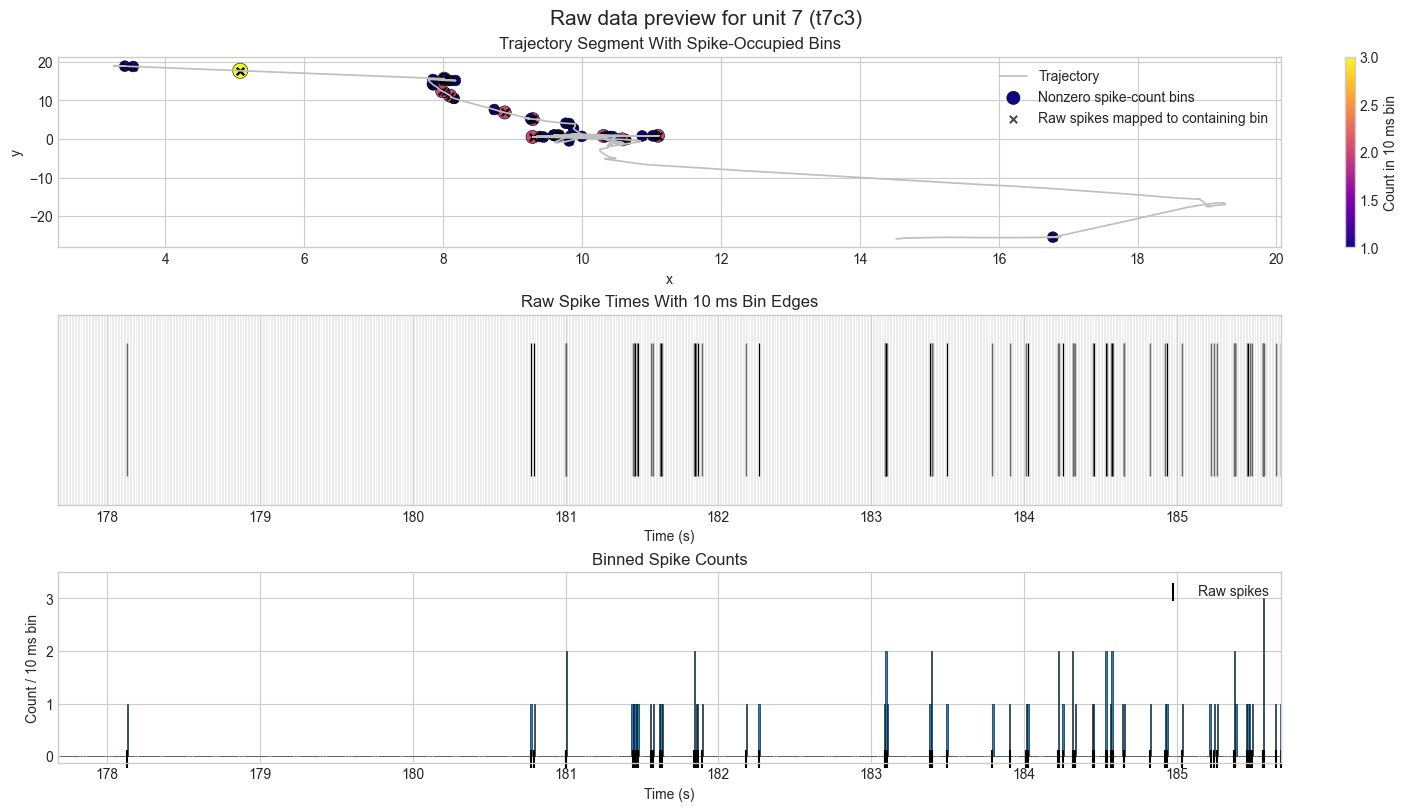

In [31]:
preview_duration_sec = 8.0
preview_bins = max(1, int(round(preview_duration_sec / bin_size)))
rolling_counts = np.convolve(counts_all, np.ones(preview_bins, dtype=np.float64), mode="valid")
best_start_bin = int(np.argmax(rolling_counts))
preview_slice = slice(best_start_bin, best_start_bin + preview_bins)

edges_preview = edges[best_start_bin : best_start_bin + preview_bins + 1]
centers_preview = centers[preview_slice]
counts_preview = counts_all[preview_slice]
position_preview = position_interp[preview_slice]

spike_mask = (unit_spikes >= edges_preview[0]) & (unit_spikes < edges_preview[-1])
spike_preview = unit_spikes[spike_mask]
spike_bin_idx = np.searchsorted(edges_preview, spike_preview, side="right") - 1
spike_bin_idx = np.clip(spike_bin_idx, 0, counts_preview.size - 1)
spike_positions = position_preview[spike_bin_idx]

print(f"Preview window: {edges_preview[0]:.2f}s to {edges_preview[-1]:.2f}s")
print(f"Spikes in window: {spike_preview.size}")
print(f"Nonzero bins in window: {np.count_nonzero(counts_preview)} / {counts_preview.size}")
print(f"Max count in a single 10 ms bin: {counts_preview.max():.0f}")

fig, axes = plt.subplots(3, 1, figsize=(14, 8), constrained_layout=True)

axes[0].plot(position_preview[:, 0], position_preview[:, 1], color="0.75", linewidth=1.25, label="Trajectory")
scatter = axes[0].scatter(
    position_preview[counts_preview > 0, 0],
    position_preview[counts_preview > 0, 1],
    c=counts_preview[counts_preview > 0],
    cmap="plasma",
    s=30 + 30 * counts_preview[counts_preview > 0],
    edgecolors="black",
    linewidths=0.4,
    label="Nonzero spike-count bins",
)
if spike_preview.size:
    axes[0].scatter(
        spike_positions[:, 0],
        spike_positions[:, 1],
        color="black",
        marker="x",
        s=28,
        alpha=0.7,
        label="Raw spikes mapped to containing bin",
    )
axes[0].set_title("Trajectory Segment With Spike-Occupied Bins")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend(loc="best")
fig.colorbar(scatter, ax=axes[0], fraction=0.046, label="Count in 10 ms bin")

axes[1].eventplot(spike_preview, lineoffsets=0.5, linelengths=0.7, linewidths=1.0, colors="black")
axes[1].vlines(edges_preview, 0.0, 1.0, color="0.85", linewidth=0.5, alpha=0.7)
axes[1].set_ylim(0.0, 1.0)
axes[1].set_yticks([])
axes[1].set_xlim(edges_preview[0], edges_preview[-1])
axes[1].set_title("Raw Spike Times With 10 ms Bin Edges")
axes[1].set_xlabel("Time (s)")

axes[2].bar(
    centers_preview,
    counts_preview,
    width=0.9 * bin_size,
    color="#1982c4",
    edgecolor="black",
    linewidth=0.4,
)
if spike_preview.size:
    axes[2].scatter(
        spike_preview,
        np.full(spike_preview.shape, -0.06),
        marker="|",
        s=180,
        color="black",
        clip_on=False,
        label="Raw spikes",
    )
axes[2].set_xlim(edges_preview[0], edges_preview[-1])
axes[2].set_ylim(-0.12, max(1.0, counts_preview.max() + 0.5))
axes[2].set_title("Binned Spike Counts")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Count / 10 ms bin")
if spike_preview.size:
    axes[2].legend(loc="upper right")

fig.suptitle(f"Raw data preview for unit {neuron} ({unit_names[neuron]})", fontsize=15)


## Fit `PolyagammaGPNegativeBinomialRegressor` With Learned `r`

The configuration below stays close to the synthetic learn-`r` demo.
The main difference is that the inputs now come from normalized 2D
position rather than synthetic random coordinates.


In [32]:
X_train_np.shape

(59998, 2)

In [33]:
reg = PolyagammaGPNegativeBinomialRegressor(
    kernel=kernel_name,
    kernel_nu=kernel_nu,
    total_count=0.5,
    learn_total_count=True,
    total_count_lr=0.1,
    total_count_update_frequency=1,
    total_count_quadrature_nodes=16,
    lengthscale_init=0.4,
    variance_init=1.0,
    max_iter=50,
    e_step_iters=1,
    final_e_step_iters=2,
    rho0=1.0,
    gamma=1e-3,
    lr=0.1,
    n_e_probes=1,
    n_m_probes=1,
    cg_tol=1e-5,
    nufft_eps=1e-4,
    spectral_eps=1e-4,
    trunc_eps=1e-4,
    prediction_batch_size=128,
    predictive_variance_method="chebyshev",
    predictive_variance_chebyshev_nodes=7,
    use_exact_weighted_toeplitz_operator=True,
    random_state=0,
    device="cpu",
    store_history=True,
    verbose=1,
)

t_fit = time.time()
reg.fit(X_train_np, y_train_np)
fit_time = time.time() - t_fit

pred_train = reg.predict_mean_count(X_train_np)
if X_test_np.shape[0] > 0:
    pred_test = reg.predict_mean_count(X_test_np)
else:
    pred_test = None

print(f"\nFit time: {fit_time:.2f} s")
print(f"Kernel: {kernel_name}" + (f" (nu={kernel_nu})" if kernel_name == "matern" else ""))
print(f"Learned lengthscale: {reg.lengthscale_:.4f}")
print(f"Learned variance: {reg.variance_:.4f}")
print(f"Learned total_count r: {reg.total_count_:.4f}")
print(f"Training MAE: {np.mean(np.abs(pred_train - y_train_np)):.5f}")
if pred_test is not None:
    print(f"Test MAE: {np.mean(np.abs(pred_test - y_test_np)):.5f}")
    print(f"Predicted mean test count: {pred_test.mean():.5f}")
    print(f"Observed mean test count: {y_test_np.mean():.5f}")
else:
    print("Held-out test split: disabled")

outer   0 lengthscale=0.36193 variance=1.10517 grad=(-1.391e+02, +2.076e+01) count_mae=0.0999
outer   1 lengthscale=0.35315 variance=1.22139 grad=(+8.099e+01, +1.873e+01) count_mae=0.0771
outer   2 lengthscale=0.35005 variance=1.35017 grad=(+2.805e+01, +2.100e+01) count_mae=0.0674
outer   3 lengthscale=0.34696 variance=1.49303 grad=(-5.073e+00, +1.977e+01) count_mae=0.0614
outer   4 lengthscale=0.34064 variance=1.65083 grad=(-3.803e+01, +1.593e+01) count_mae=0.0584
outer   5 lengthscale=0.33061 variance=1.82297 grad=(-5.575e+01, +1.158e+01) count_mae=0.0555
outer   6 lengthscale=0.31699 variance=2.01412 grad=(-7.562e+01, +1.364e+01) count_mae=0.0543
outer   7 lengthscale=0.31374 variance=2.22115 grad=(+1.168e+02, +8.302e+00) count_mae=0.0528
outer   8 lengthscale=0.32328 variance=2.42072 grad=(+2.828e+02, -4.736e-01) count_mae=0.0511
outer   9 lengthscale=0.33833 variance=2.63933 grad=(+1.847e+02, +6.779e+00) count_mae=0.0502
outer  10 lengthscale=0.34519 variance=2.87776 grad=(-1.573e

## Evaluate The Fitted Spatial Field

As in the synthetic notebook, we inspect:

- the latent posterior mean on a regular grid
- the predictive latent variance
- the implied mean count / firing-rate map

We also compare the GP fit against a smoothed empirical rate map computed
directly from the binned spikes and occupancy.


In [34]:
latent_grid = reg.decision_function(X_grid_np)
var_grid = reg.predictive_variance(X_grid_np)
mean_count_grid = reg.total_count_ * np.exp(latent_grid + 0.5 * var_grid)

mean_count_all = reg.predict_mean_count(X_all_np)

latent_grid_img = latent_grid.reshape(grid_size, grid_size)
var_grid_img = var_grid.reshape(grid_size, grid_size)
mean_rate_grid_img = (mean_count_grid.reshape(grid_size, grid_size) / bin_size)

def smoothed_rate_map(coords, weights, x_edges, y_edges, *, bin_size, sigma=1.0):
    occupancy, _, _ = np.histogram2d(coords[:, 0], coords[:, 1], bins=[x_edges, y_edges])
    weighted_sum, _, _ = np.histogram2d(
        coords[:, 0],
        coords[:, 1],
        bins=[x_edges, y_edges],
        weights=weights,
    )
    occ_smooth = gaussian_filter(occupancy, sigma=sigma)
    weighted_smooth = gaussian_filter(weighted_sum, sigma=sigma)
    rate = weighted_smooth / np.maximum(occ_smooth * bin_size, 1e-12)
    rate[occ_smooth < 1e-6] = np.nan
    return rate, occupancy

map_bins = 20
x_edges = np.linspace(coord_mins[0], coord_maxs[0], map_bins + 1)
y_edges = np.linspace(coord_mins[1], coord_maxs[1], map_bins + 1)

empirical_rate_map, occupancy_map = smoothed_rate_map(
    position_interp,
    counts_all,
    x_edges,
    y_edges,
    bin_size=bin_size,
    sigma=1.0,
)
predicted_rate_map, _ = smoothed_rate_map(
    position_interp,
    mean_count_all,
    x_edges,
    y_edges,
    bin_size=bin_size,
    sigma=1.0,
)

print(f"Mean predicted count over all bins: {mean_count_all.mean():.5f}")
print(f"Mean observed count over all bins: {counts_all.mean():.5f}")


Mean predicted count over all bins: 0.02846
Mean observed count over all bins: 0.02095


Text(0.5, 0.98, 'Grid-cell rate maps for unit 7 (t7c3)')

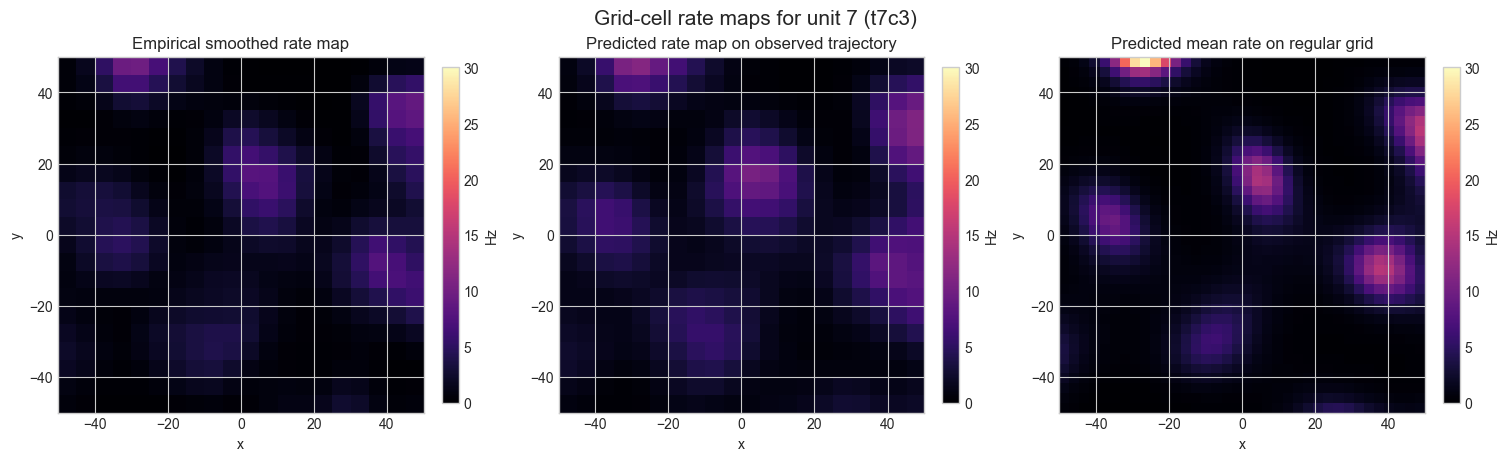

In [35]:
extent = [coord_mins[0], coord_maxs[0], coord_mins[1], coord_maxs[1]]
map_vmax = max(
    float(np.nanmax(empirical_rate_map)),
    float(np.nanmax(predicted_rate_map)),
    float(np.nanmax(mean_rate_grid_img)),
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

im0 = axes[0].imshow(
    empirical_rate_map.T,
    origin="lower",
    extent=extent,
    cmap="magma",
    aspect="auto",
    vmin=0.0,
    vmax=map_vmax,
)
axes[0].set_title("Empirical smoothed rate map")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(im0, ax=axes[0], fraction=0.046, label="Hz")

im1 = axes[1].imshow(
    predicted_rate_map.T,
    origin="lower",
    extent=extent,
    cmap="magma",
    aspect="auto",
    vmin=0.0,
    vmax=map_vmax,
)
axes[1].set_title("Predicted rate map on observed trajectory")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
fig.colorbar(im1, ax=axes[1], fraction=0.046, label="Hz")

im2 = axes[2].imshow(
    mean_rate_grid_img.T,
    origin="lower",
    extent=extent,
    cmap="magma",
    aspect="auto",
    vmin=0.0,
    vmax=map_vmax,
)
axes[2].set_title("Predicted mean rate on regular grid")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
fig.colorbar(im2, ax=axes[2], fraction=0.046, label="Hz")

fig.suptitle(f"Grid-cell rate maps for unit {neuron} ({unit_names[neuron]})", fontsize=15)


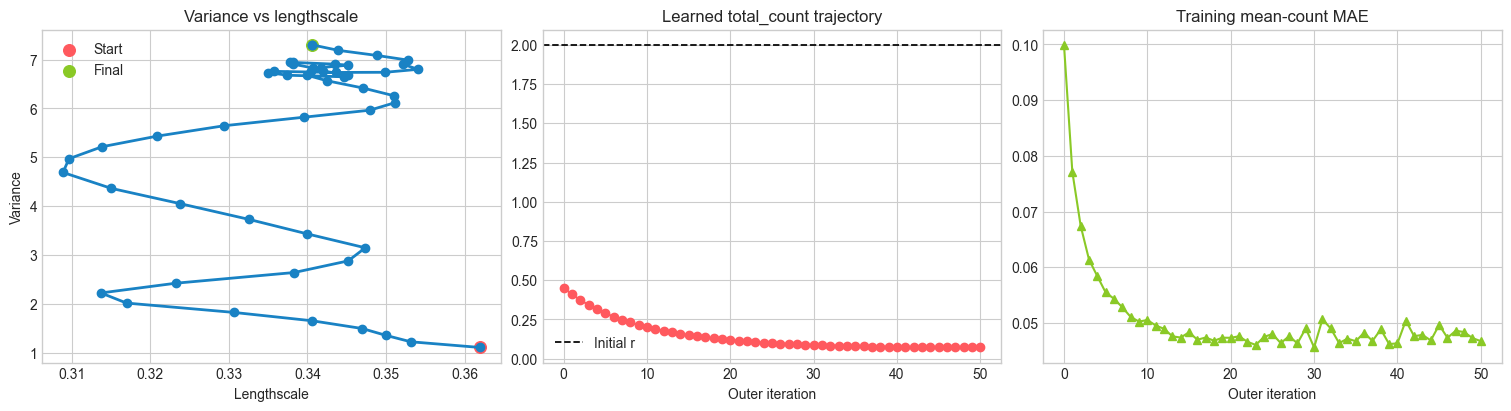

In [36]:
history = reg.history_
iters = np.array([row["iter"] for row in history], dtype=float)
lengthscales = np.array([row["lengthscale"] for row in history], dtype=float)
variances = np.array([row["variance"] for row in history], dtype=float)
total_counts = np.array([row["total_count"] for row in history], dtype=float)
count_mae = np.array([row["mean_count_mae"] for row in history], dtype=float)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].plot(lengthscales, variances, color="#1982c4", marker="o", linewidth=2)
axes[0].scatter(lengthscales[0], variances[0], color="#ff595e", s=70, label="Start")
axes[0].scatter(lengthscales[-1], variances[-1], color="#8ac926", s=70, label="Final")
axes[0].set_title("Variance vs lengthscale")
axes[0].set_xlabel("Lengthscale")
axes[0].set_ylabel("Variance")
axes[0].legend(loc="best")

axes[1].plot(iters, total_counts, marker="o", color="#ff595e")
axes[1].axhline(2.0, color="black", linestyle="--", linewidth=1.25, label="Initial r")
axes[1].set_title("Learned total_count trajectory")
axes[1].set_xlabel("Outer iteration")
axes[1].legend(loc="best")

axes[2].plot(iters, count_mae, marker="^", color="#8ac926")
axes[2].set_title("Training mean-count MAE")
axes[2].set_xlabel("Outer iteration")

plt.show()


In [37]:
summary = {
    "unit": neuron,
    "unit_name": unit_names[neuron],
    "kernel": kernel_name,
    "kernel_nu": kernel_nu if kernel_name == "matern" else None,
    "used_all_data_for_training": bool(use_all_data_for_training),
    "fit_time_sec": fit_time,
    "lengthscale": float(reg.lengthscale_),
    "variance": float(reg.variance_),
    "total_count": float(reg.total_count_),
    "train_mae": float(np.mean(np.abs(pred_train - y_train_np))),
    "test_mae": None if pred_test is None else float(np.mean(np.abs(pred_test - y_test_np))),
    "pred_test_mean": None if pred_test is None else float(pred_test.mean()),
    "obs_test_mean": None if pred_test is None else float(y_test_np.mean()),
}
summary

{'unit': 7,
 'unit_name': 't7c3',
 'kernel': 'squared_exponential',
 'kernel_nu': None,
 'used_all_data_for_training': True,
 'fit_time_sec': 4.422629117965698,
 'lengthscale': 0.34062400460243225,
 'variance': 7.299432754516602,
 'total_count': 0.0715686878720387,
 'train_mae': 0.04672376849981124,
 'test_mae': None,
 'pred_test_mean': None,
 'obs_test_mean': None}